In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('HI-Small_Trans.csv')

df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


# Data Cleaning

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           str    
 1   From Bank           int64  
 2   Account             str    
 3   To Bank             int64  
 4   Account.1           str    
 5   Amount Received     float64
 6   Receiving Currency  str    
 7   Amount Paid         float64
 8   Payment Currency    str    
 9   Payment Format      str    
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), str(6)
memory usage: 426.2 MB


In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 5078336 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           str    
 1   From Bank           int64  
 2   Account             str    
 3   To Bank             int64  
 4   Account.1           str    
 5   Amount Received     float64
 6   Receiving Currency  str    
 7   Amount Paid         float64
 8   Payment Currency    str    
 9   Payment Format      str    
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), str(6)
memory usage: 464.9 MB


In [7]:
print(df.isna().sum())

Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64


# Split

In [9]:
# Convert the timestamp column into actual dates
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="raise")

# Arrange transactions from oldest to newest
df = df.sort_values("Timestamp").reset_index(drop=True)

# Find timestamps around the 70% and 85% positions
train_cutoff = df["Timestamp"].iloc[int(len(df) * 0.70)]
test_cutoff = df["Timestamp"].iloc[int(len(df) * 0.85)]

# Oldest ~70%: training
train_df = df[df["Timestamp"] < train_cutoff].copy()

# Next ~15%: validation
val_df = df[
    (df["Timestamp"] >= train_cutoff)
    & (df["Timestamp"] < test_cutoff)
].copy()

# Newest ~15%: testing
test_df = df[df["Timestamp"] >= test_cutoff].copy()

for name, data in [
    ("Training", train_df),
    ("Validation", val_df),
    ("Testing", test_df),
]:
    print(f"\n{name}: {len(data):,} transactions")
    print("From:", data["Timestamp"].min())
    print("To:  ", data["Timestamp"].max())

    # Change this if your label column has a different name
    print(data["Is Laundering"].value_counts())


Training: 3,554,647 transactions
From: 2022-09-01 00:00:00
To:   2022-09-07 14:54:00
Is Laundering
0    3551791
1       2856
Name: count, dtype: int64

Validation: 761,590 transactions
From: 2022-09-07 14:55:00
To:   2022-09-09 03:15:00
Is Laundering
0    760830
1       760
Name: count, dtype: int64

Testing: 762,099 transactions
From: 2022-09-09 03:16:00
To:   2022-09-18 16:18:00
Is Laundering
0    760538
1      1561
Name: count, dtype: int64


# Features

In [11]:
import numpy as np
# When did the transaction happen?
df["hour"] = df["Timestamp"].dt.hour
df["day_of_week"] = df["Timestamp"].dt.dayofweek

# Monday = 0, Sunday = 6
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Did the transfer go between different banks?
df["different_bank"] = (
    df["From Bank"] != df["To Bank"]
).astype(int)

# Compress large amounts so their scale is less extreme
# Assumes amounts are nonnegative
df["log_amount"] = np.log1p(df["Amount Paid"])

# Use bank + account to identify a sender.
# Include currency so we don't average different currencies together.
sender_keys = ["From Bank", "Account", "Payment Currency"]

# Combine transactions that share a sender, currency, and timestamp
history = (
    df.groupby(sender_keys + ["Timestamp"], as_index=False)
      .agg(
          transactions_at_time=("Amount Paid", "size"),
          amount_at_time=("Amount Paid", "sum")
      )
      .sort_values("Timestamp")
)

# Count transactions strictly BEFORE the current timestamp
history["previous_transaction_count"] = (
    history.groupby(sender_keys)["transactions_at_time"].cumsum()
    - history["transactions_at_time"]
)

# Sum amounts strictly BEFORE the current timestamp
history["previous_total_amount"] = (
    history.groupby(sender_keys)["amount_at_time"].cumsum()
    - history["amount_at_time"]
)

# Average prior amount; stays missing when there is no history
history["previous_average_amount"] = (
    history["previous_total_amount"]
    / history["previous_transaction_count"].replace(0, np.nan)
)

# Attach the historical features to each original transaction
df = df.merge(
    history[
        sender_keys
        + [
            "Timestamp",
            "previous_transaction_count",
            "previous_average_amount"
        ]
    ],
    on=sender_keys + ["Timestamp"],
    how="left",
    validate="many_to_one"
)

# Compare this transaction with the sender's previous average
df["amount_vs_previous_average"] = (
    df["Amount Paid"]
    / df["previous_average_amount"].replace(0, np.nan)
)

feature_columns = [
    "hour",
    "day_of_week",
    "is_weekend",
    "different_bank",
    "log_amount",
    "previous_transaction_count",
    "previous_average_amount",
    "amount_vs_previous_average"
]

df[["Timestamp", "Amount Paid"] + feature_columns].head(10)

train_df = df[df["Timestamp"] < train_cutoff].copy()

val_df = df[
    (df["Timestamp"] >= train_cutoff)
    & (df["Timestamp"] < test_cutoff)
].copy()

test_df = df[df["Timestamp"] >= test_cutoff].copy()

# Train (Logistic Regression)

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

numeric_features = [
    "hour",
    "day_of_week",
    "is_weekend",
    "different_bank",
    "log_amount",
    "previous_transaction_count",
    "previous_average_amount",
    "amount_vs_previous_average"
]

categorical_features = [
    "Payment Currency",
    "Payment Format"
]

features = numeric_features + categorical_features

# Training inputs and correct answers
X_train = train_df[features].copy()
y_train = train_df["Is Laundering"].copy()

# Validation inputs and correct answers
X_val = val_df[features].copy()
y_val = val_df["Is Laundering"].copy()

# Treat any infinite numeric values as missing
X_train[numeric_features] = X_train[numeric_features].replace(
    [np.inf, -np.inf], np.nan
)

X_val[numeric_features] = X_val[numeric_features].replace(
    [np.inf, -np.inf], np.nan
)

# Numeric columns: fill missing values, then scale
numeric_processor = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

# Text columns: fill missing values, then encode as numeric columns
categorical_processor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Apply the appropriate preparation to each group of columns
preprocessor = ColumnTransformer([
    ("numeric", numeric_processor, numeric_features),
    ("categorical", categorical_processor, categorical_features)
])


model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

model.fit(X_train, y_train)

print("Training complete!")

# Predicted class: 0 or 1
val_predictions = model.predict(X_val)

# Score for class 1: laundering
val_scores = model.predict_proba(X_val)[:, 1]

print("First 10 predictions:", val_predictions[:10])
print("First 10 scores:", val_scores[:10])

Training complete!
First 10 predictions: [0 0 0 0 0 0 1 0 0 0]
First 10 scores: [0.09392367 0.13134752 0.21249792 0.10529612 0.1118953  0.16625895
 0.66233165 0.11164443 0.23552678 0.27837514]


# Model (Random Forest)

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.pipeline import Pipeline

# Keep the trained logistic regression
logistic_model = model

random_forest_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", RandomForestClassifier(
        n_estimators=50,          # Fewer trees
        max_depth=10,             # Smaller trees
        min_samples_leaf=20,
        max_samples=100_000,      # At most 100k sampled rows per tree
        class_weight="balanced_subsample",
        n_jobs=2,                # Leave some CPU capacity available
        random_state=42
    ))
])

random_forest_model.fit(X_train, y_train)

print("Random forest training complete!")

Random forest training complete!


# Logistic Regression Vs. Random Forest

In [15]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix
)

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model
}

results = []
validation_scores = {}

for name, trained_model in models.items():

    # Get laundering scores
    scores = trained_model.predict_proba(X_val)[:, 1]
    validation_scores[name] = scores

    # Start with a cutoff of 0.5
    predictions = (scores >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val, predictions, labels=[0, 1]
    ).ravel()

    results.append({
        "Model": name,
        "Precision": precision_score(
            y_val, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_val, predictions, zero_division=0
        ),
        "F1": f1_score(
            y_val, predictions, zero_division=0
        ),
        "Average Precision": average_precision_score(y_val, scores),
        "Laundering Caught": tp,
        "Laundering Missed": fn,
        "False Alerts": fp,
        "Total Alerts": tp + fp
    })

comparison = pd.DataFrame(results).set_index("Model")

display(comparison.round(4))

,Precision,Recall,F1,Average Precision,Laundering Caught,Laundering Missed,False Alerts,Total Alerts
Model,,,,,,,,
Logistic Regression,0.0056,0.9289,0.0110,0.0068,706,54,126389,127095
Random Forest,0.0327,0.6645,0.0623,0.1025,505,255,14937,15442


In [16]:
import numpy as np

review_fraction = 0.01
number_to_review = max(1, int(len(y_val) * review_fraction))

actual_labels = y_val.to_numpy()
total_laundering = (actual_labels == 1).sum()

budget_results = []

for name, scores in validation_scores.items():

    # Highest scores first; ties retain the original row order
    top_indices = np.argsort(
        -scores, kind="stable"
    )[:number_to_review]

    caught = (actual_labels[top_indices] == 1).sum()

    budget_results.append({
        "Model": name,
        "Transactions Reviewed": number_to_review,
        "Laundering Caught": caught,
        "False Alerts": number_to_review - caught,
        "Precision at Budget": caught / number_to_review,
        "Recall at Budget": (
            caught / total_laundering
            if total_laundering > 0 else np.nan
        )
    })

budget_comparison = pd.DataFrame(budget_results).set_index("Model")

display(budget_comparison.round(4))

,Transactions Reviewed,Laundering Caught,False Alerts,Precision at Budget,Recall at Budget
Model,,,,,
Logistic Regression,7615,16,7599,0.0021,0.0211
Random Forest,7615,380,7235,0.0499,0.5000


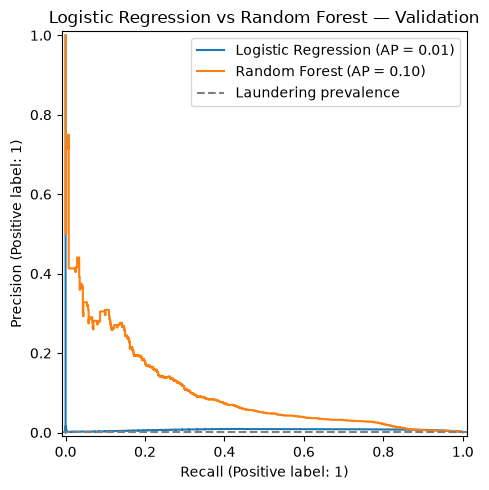

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(8, 5))

for name, scores in validation_scores.items():
    PrecisionRecallDisplay.from_predictions(
        y_val,
        scores,
        name=name,
        ax=ax
    )

# Reference: the proportion of transactions labelled laundering
ax.axhline(
    y=y_val.mean(),
    color="gray",
    linestyle="--",
    label="Laundering prevalence"
)

ax.set_title("Logistic Regression vs Random Forest — Validation")
ax.legend()
plt.tight_layout()
plt.show()

# Inspection

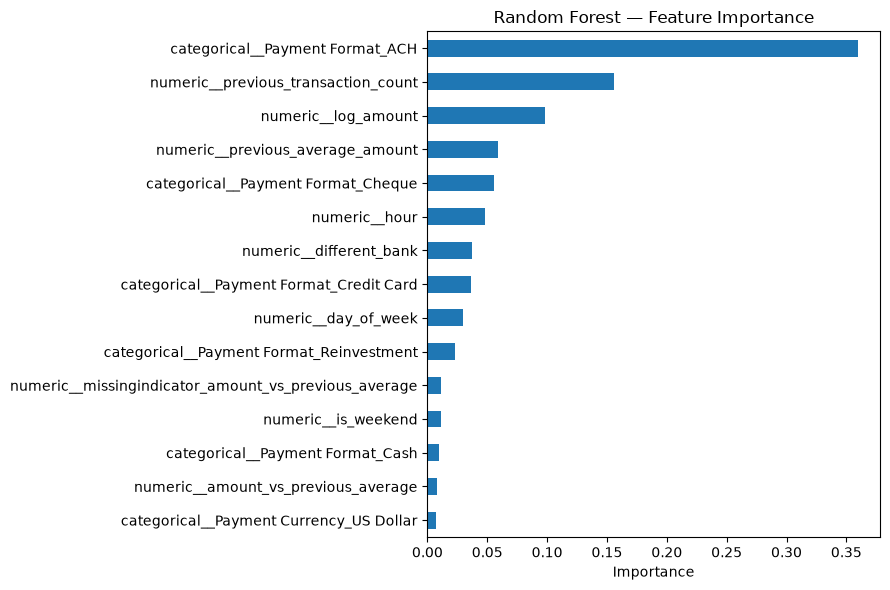

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = pd.Series(
    random_forest_model
    .named_steps["classifier"]
    .feature_importances_,
    index=feature_names
).sort_values(ascending=False)

importance.head(15).sort_values().plot.barh(figsize=(9, 6))

plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [19]:
# Ensure transaction details and model inputs have the same row order
assert val_df.index.equals(X_val.index)

alerts = val_df.copy()

alerts["risk_score"] = random_forest_model.predict_proba(X_val)[:, 1]

# Descriptive context for an analyst—not model explanations
def describe_transaction(row):
    observations = []

    ratio = row["amount_vs_previous_average"]

    if pd.notna(ratio) and ratio >= 5:
        observations.append(
            f"Amount is {ratio:.1f}× the sender's prior average"
        )

    if row["previous_transaction_count"] == 0:
        observations.append("No prior sender history in this currency")

    if row["different_bank"] == 1:
        observations.append("Transfer between different banks")

    return "; ".join(observations) or "Review transaction history"

alerts["review_context"] = alerts.apply(
    describe_transaction, axis=1
)

alerts = alerts.sort_values("risk_score", ascending=False)

display(
    alerts[
        [
            "Timestamp",
            "Account",
            "Account.1",
            "Amount Paid",
            "Payment Currency",
            "risk_score",
            "review_context",
            "Is Laundering"
        ]
    ].head(10)
)

,Timestamp,Account,Account.1,Amount Paid,Payment Currency,risk_score,review_context,Is Laundering
3562258,2022-09-07 15:18:00,805AD2D20,8027C1CE0,12020.12,US Dollar,0.981491,No prior sender history in this currency; Tran...,1
3559817,2022-09-07 15:10:00,81359A920,81359A740,16740.17,US Dollar,0.981491,No prior sender history in this currency; Tran...,0
3574504,2022-09-07 15:55:00,8013028A0,803BCC3E0,16852.38,Euro,0.980719,No prior sender history in this currency; Tran...,1
3562886,2022-09-07 15:19:00,8022EFC20,800E3D880,13501.86,Euro,0.980719,No prior sender history in this currency; Tran...,1
3574325,2022-09-07 15:54:00,8054913D0,8002F2E90,12268.52,Euro,0.980719,No prior sender history in this currency; Tran...,1
3561868,2022-09-07 15:16:00,800B11170,800A54A70,13973.26,Euro,0.980719,No prior sender history in this currency; Tran...,1
3555086,2022-09-07 14:56:00,812ADAA80,812ADAB20,30974.26,Euro,0.980719,No prior sender history in this currency; Tran...,0
3616264,2022-09-07 18:02:00,80B0C3F40,811D80C30,23526.06,Saudi Riyal,0.961838,No prior sender history in this currency; Tran...,1
4017933,2022-09-08 13:55:00,80878BA20,808B1C350,6791.69,US Dollar,0.961725,No prior sender history in this currency; Tran...,1
3930904,2022-09-08 09:29:00,806FEB6C0,806FEB170,34966.73,US Dollar,0.961725,No prior sender history in this currency; Tran...,0


# Dashboard

In [20]:
from pathlib import Path

Path("app").mkdir(exist_ok=True)

alerts.to_csv("app/validation_alerts.csv", index=False)

print("Saved to:", Path("app/validation_alerts.csv").resolve())

Saved to: /Users/ayaankukreja/Desktop/aml-monitoring/app/validation_alerts.csv


In [21]:
%pip install streamlit

  Using cached altair-6.3.0-py3-none-any.whl.metadata (11 kB)
  Using cached pydeck-0.9.3-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached protobuf-7.36.2-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached pyarrow-25.0.1-cp312-cp312-macosx_12_0_arm64.whl.metadata (3.0 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached starlette-1.7.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached uvicorn-0.54.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached httptools-0.8.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (3.5 kB)
  Using cached python_multipart-0.0.32-py3-none-any.whl.metadata (2.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 15.3 MB/s  0:00:00eta 0:00:01
Using cached altair-6.3.0-py3-none-any.whl (797 kB)
Using cached httptools-0.8.0-cp312-cp312-macosx_11_0_arm64.whl (113 kB)
Using cached protobuf-7.36.2-cp310-abi3-macosx_10_9_universal2.whl (456 kB)
Using cached pyarrow-25.0.1-cp312-cp312-macosx_12_0_arm64.

In [22]:
%%writefile app/dashboard.py
from pathlib import Path

import pandas as pd
import streamlit as st

st.set_page_config(page_title="AML Monitoring", layout="wide")

@st.cache_data
def load_alerts():
    path = Path(__file__).parent / "validation_alerts.csv"

    return pd.read_csv(
        path,
        dtype={"Account": str, "Account.1": str}
    ).sort_values("risk_score", ascending=False).reset_index(drop=True)

alerts = load_alerts()

st.title("AML Transaction Monitoring")
st.caption(
    "Random forest • Synthetic validation data • "
    "Retrospective review simulation"
)

st.sidebar.header("Review capacity")

budget = int(st.sidebar.number_input(
    "Transactions to review",
    min_value=1,
    max_value=len(alerts),
    value=min(100, len(alerts)),
    step=1
))

selected = alerts.head(budget)

caught = int(selected["Is Laundering"].sum())
total_positive = int(alerts["Is Laundering"].sum())
precision = caught / budget
recall = caught / total_positive if total_positive else 0

a, b, c, d = st.columns(4)

a.metric("Transactions reviewed", f"{budget:,}")
b.metric("Labelled laundering caught", f"{caught:,}")
c.metric("Precision at budget", f"{precision:.1%}")
d.metric("Recall at budget", f"{recall:.1%}")

st.caption(
    "The budget applies to the full validation period, not one day. "
    "Scores are rankings, not calibrated laundering probabilities."
)

st.subheader("Ranked alert queue")

columns = [
    "Timestamp",
    "From Bank",
    "Account",
    "To Bank",
    "Account.1",
    "Amount Paid",
    "Payment Currency",
    "risk_score",
    "review_context"
]

show_labels = st.checkbox("Show known labels for evaluation")

if show_labels:
    columns.append("Is Laundering")

st.dataframe(
    selected[columns],
    use_container_width=True,
    hide_index=True
)

st.subheader("Inspect a transaction")

rank = int(st.number_input(
    "Alert rank",
    min_value=1,
    max_value=budget,
    value=1
))

transaction = selected.iloc[rank - 1]

st.write(
    f"**Sender:** {transaction['From Bank']} / "
    f"{transaction['Account']}"
)

st.write(
    f"**Receiver:** {transaction['To Bank']} / "
    f"{transaction['Account.1']}"
)

st.write(
    f"**Amount:** {transaction['Amount Paid']:,.2f} "
    f"{transaction['Payment Currency']}"
)

st.write(f"**Model score:** {transaction['risk_score']:.4f}")
st.info(transaction["review_context"])

st.caption(
    "Review context describes transaction attributes. "
    "It does not explain the model's exact reasoning or establish wrongdoing."
)

Writing app/dashboard.py
